<a href="https://www.kaggle.com/code/stutisharma22/predicting-road-accident-risk?scriptVersionId=271049625" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

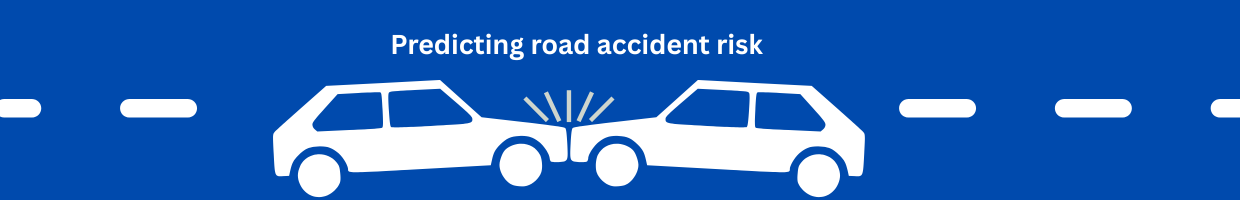

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


# **Importing required libraries**

In [2]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

# **Loading the data**

In [3]:
#reading data from the files
df_train= pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
df_test= pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

In [4]:
#resetting the index
df_train= df_train.set_index('id')
df_test= df_test.set_index('id')

In [5]:
#viewing first five rows of the dataset
df_train.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [6]:
#number of columns and data types in the train dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 41.5+ MB


In [7]:
df_train.shape, df_test.shape

((517754, 13), (172585, 12))

In [8]:
#summary statistics of numerical columns in train dataset
df_train.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,2.491511,0.488719,46.112575,1.187970,0.352377
std,1.120434,0.272563,15.788521,0.895961,0.166417
min,1.000000,0.000000,25.000000,0.000000,0.000000
25%,1.000000,0.260000,35.000000,1.000000,0.230000
50%,2.000000,0.510000,45.000000,1.000000,0.340000
75%,3.000000,0.710000,60.000000,2.000000,0.460000
max,4.000000,1.000000,70.000000,7.000000,1.000000


In [9]:
#number of unique values in the columns
df_train.nunique()

road_type                   3
num_lanes                   4
curvature                 261
speed_limit                 5
lighting                    3
weather                     3
road_signs_present          2
public_road                 2
time_of_day                 3
holiday                     2
school_season               2
num_reported_accidents      8
accident_risk              98
dtype: int64

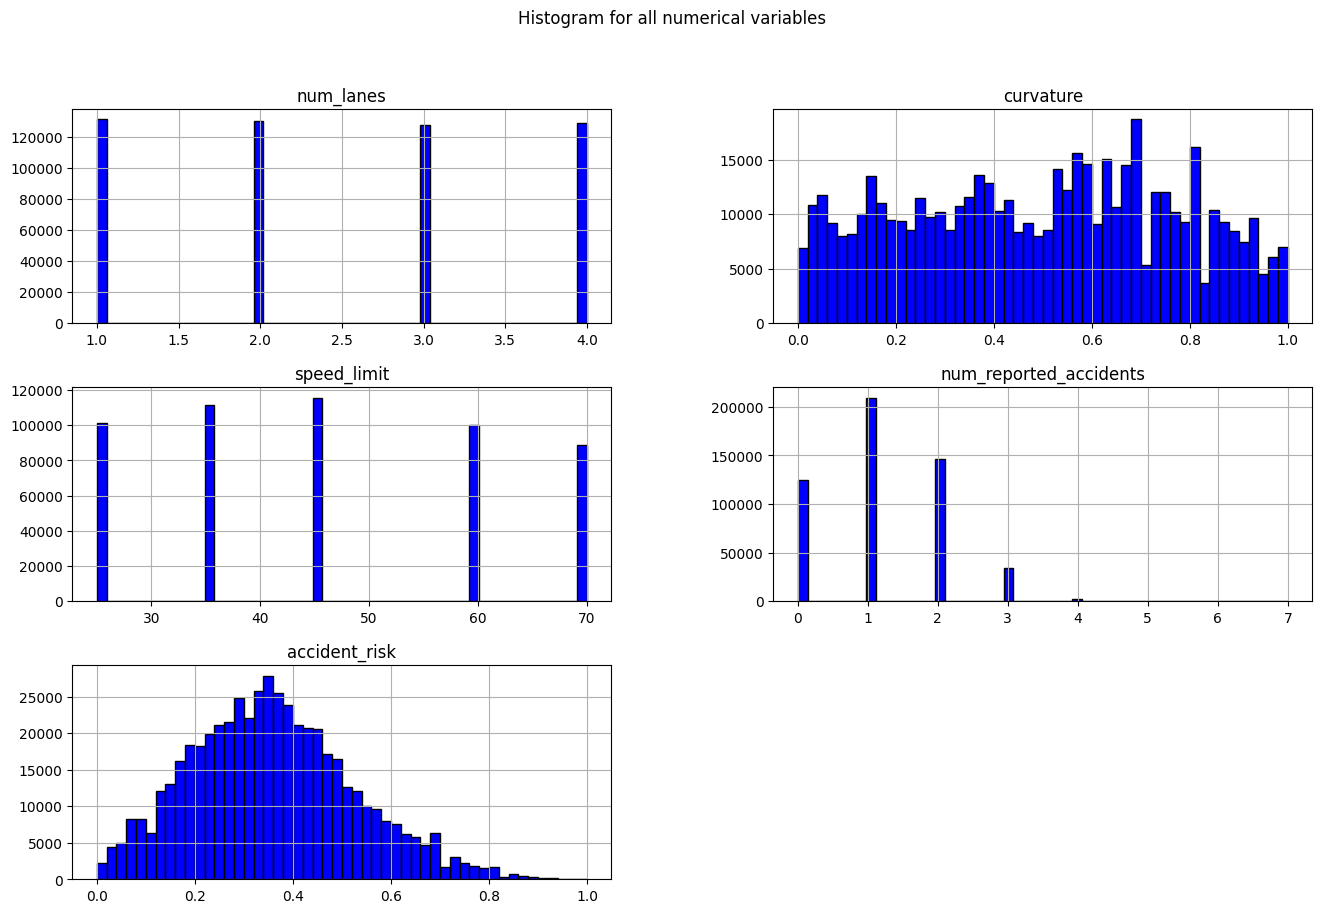

In [10]:
#plotting histogram for all the input variables
df_train.hist(figsize=(16,10), bins=50, color='blue', edgecolor='black')
plt.suptitle("Histogram for all numerical variables")
plt.show()

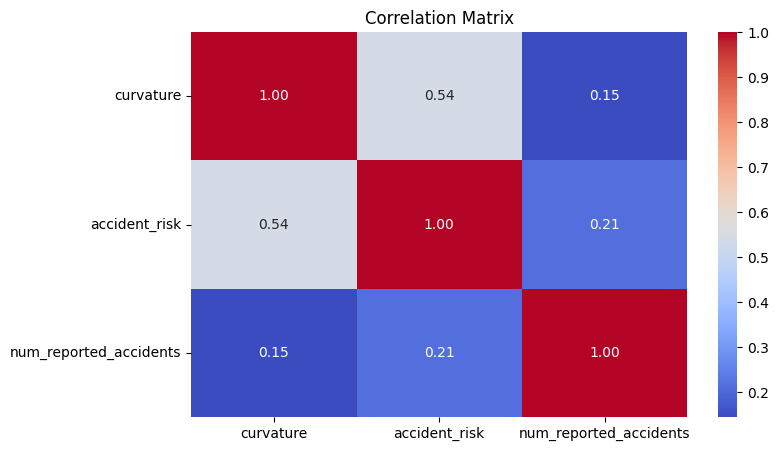

In [11]:
numerical_variables= df_train[['curvature', 'accident_risk','num_reported_accidents']]
correlation_matrix= numerical_variables.corr()
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

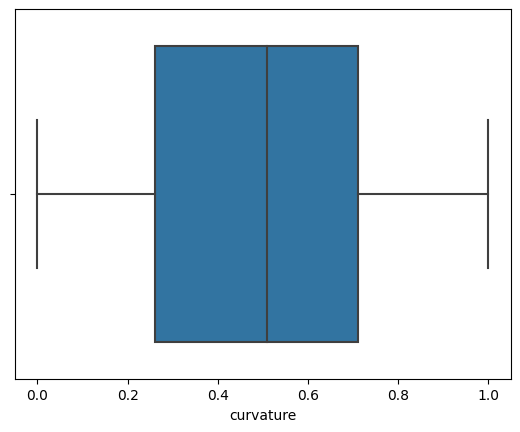

In [12]:
sns.boxplot(data= df_train,x='curvature' )
plt.show()

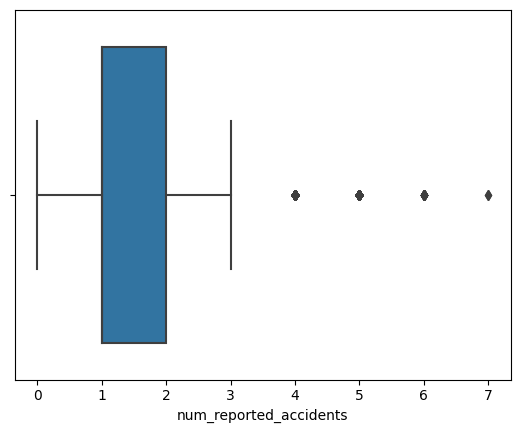

In [13]:
sns.boxplot(data= df_train,x='num_reported_accidents' )
plt.show()

# **Feature processing**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


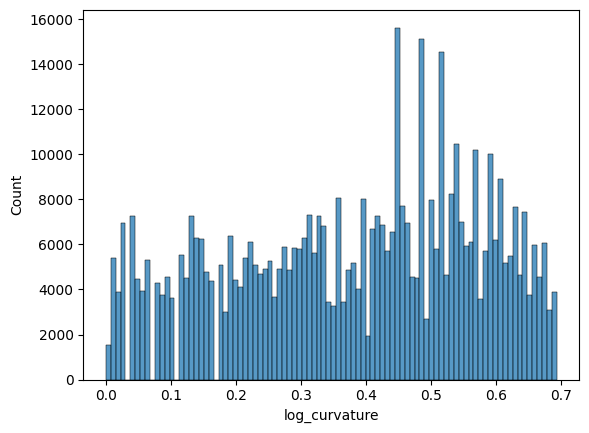

In [14]:
df_train['log_curvature'] = np.log1p(df_train['curvature'])
df_test['log_curvature'] = np.log1p(df_test['curvature'])
sns.histplot(data=df_train, x='log_curvature')
plt.show()

In [15]:
#Creating feature interactions

df_train['speed_curvature']= df_train['speed_limit'] * df_train['curvature']
df_train['lanes_is_public']= df_train['num_lanes'] * df_train['public_road']==True
df_train['is_night_rainy']= (df_train['time_of_day'] == 'night') * (df_train['weather']=='rainy')
df_train['accidents_per_lane']= df_train['num_reported_accidents'] / df_train['num_lanes']
df_train['accidents_per_speed_limit']= df_train['num_reported_accidents'] / df_train['speed_limit']
df_train.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,log_curvature,speed_curvature,lanes_is_public,is_night_rainy,accidents_per_lane,accidents_per_speed_limit
id,,,,,,,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,0.058269,2.10,False,False,0.50,0.028571
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,0.688135,34.65,False,False,0.00,0.000000
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,0.488580,44.10,False,False,0.50,0.028571
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,0.067659,2.45,False,False,0.25,0.028571
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,0.457425,34.80,False,False,1.00,0.016667


In [16]:
df_test['speed_curvature']= df_test['speed_limit'] * df_test['curvature']
df_test['lanes_is_public']= df_test['num_lanes'] * df_test['public_road']==True
df_test['is_night_rainy']= (df_test['time_of_day'] == 'night') * (df_test['weather']=='rainy')
df_test['accidents_per_lane']= df_test['num_reported_accidents'] / df_test['num_lanes']
df_test['accidents_per_speed_limit']= df_test['num_reported_accidents'] / df_test['speed_limit']
df_test.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,log_curvature,speed_curvature,lanes_is_public,is_night_rainy,accidents_per_lane,accidents_per_speed_limit
id,,,,,,,,,,,,,,,,,,
517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1,0.292670,15.30,False,False,0.5,0.022222
517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0,0.039221,1.80,False,False,0.0,0.000000
517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1,0.463734,20.65,False,False,0.5,0.028571
517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2,0.667829,33.25,False,False,0.5,0.057143
517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3,0.620576,30.10,False,False,1.5,0.085714


In [17]:
#categorical variables in the dataset
categorical_variables= df_train.select_dtypes(include=['object','category']).columns.tolist()
categorical_variables

['road_type', 'lighting', 'weather', 'time_of_day']

In [18]:
#Encoding categorical variables using one-hot encoding
df_train= pd.get_dummies(df_train, columns=categorical_variables, drop_first=True)
df_test= pd.get_dummies(df_test, columns=categorical_variables, drop_first=True)

In [19]:
#replacing True and False with 1 and 0
df_train=df_train.replace({True: 1, False: 0})
df_test=df_test.replace({True: 1, False: 0})

/tmp/ipykernel_13/751953346.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train=df_train.replace({True: 1, False: 0})
/tmp/ipykernel_13/751953346.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test=df_test.replace({True: 1, False: 0})


# **Standardizing the data**

In [20]:
#Standardizing the features
scaler= RobustScaler()
X= df_train.drop('accident_risk', axis=1)
y= df_train['accident_risk']
X_test= df_test.copy()
X_scaled= scaler.fit_transform(X)
X_test_scaled= scaler.transform(X_test)
X_scaled= pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
X_test_scaled= pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# **Setting up the KFold**

In [21]:
#setting up the KFold
kf= KFold(n_splits= 5, shuffle= True, random_state= 42)  

In [22]:
#Initializing storage
oof_lgb= np.zeros(len(X))
oof_xgb= np.zeros(len(X))
oof_cat= np.zeros(len(X))

preds_lgb= np.zeros(len(X_test))
preds_xgb= np.zeros(len(X_test))
preds_cat= np.zeros(len(X_test))

# **Models used**

In [23]:
#models with parameters
model1= lgb.LGBMRegressor(objective='regression', random_state=42, learning_rate=0.03, n_estimators=1000, num_leaves=64, max_depth=-1, 
                          subsample= 0.8,colsample_bytree=0.8 )
model2= xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, 
                         eval_metric='rmse', tree_method= 'hist', random_state=42)
model3= cb.CatBoostRegressor(iterations=1000, learning_rate=0.03, depth=6, random_seed= 42, verbose= False)


# **Model training**

In [24]:
#training and predicting
for fold, (train_idx, valid_idx) in enumerate(kf.split(X_scaled,y)):
    print(f"\n--------Fold{fold+1}---------")
    X_train, X_valid= X_scaled.iloc[train_idx], X_scaled.iloc[valid_idx]
    y_train, y_valid= y.iloc[train_idx], y.iloc[valid_idx]

    model1.fit(X_train,y_train, eval_set=[(X_valid, y_valid)], eval_metric= 'rmse')
    oof_lgb[valid_idx]= model1.predict(X_valid)
    preds_lgb += model1.predict(X_test_scaled) / kf.n_splits

    model2.fit(X_train,y_train)
    oof_xgb[valid_idx]= model2.predict(X_valid)
    preds_xgb += model2.predict(X_test_scaled) / kf.n_splits

    model3.fit(X_train,y_train)
    oof_cat[valid_idx]= model3.predict(X_valid)
    preds_cat += model3.predict(X_test_scaled) / kf.n_splits



--------Fold1---------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.093475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 592
[LightGBM] [Info] Number of data points in the train set: 414203, number of used features: 21
[LightGBM] [Info] Start training from score 0.352605

--------Fold2---------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.084868 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 591
[LightGBM] [Info] Number of data points in the train set: 414203, number of used features: 21
[LightGBM] [Info] Start training from score 0.352104

--------Fold3---------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.074805 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 559
[LightGBM] [Info] Number of data points in the tr

# **Weight optimized ensemble** 

In [25]:
X_stack= np.vstack([oof_lgb, oof_xgb, oof_cat]).T

In [26]:
def rmse_loss(weights, alpha= 0.01):
    blended= np.dot(X_stack, weights)
    return mean_squared_error(y, blended, squared= False) + alpha * np.sum(weights ** 2)

In [27]:
init_weights= [1/3, 1/3, 1/3]
constraints= {'type': 'eq', 'fun': lambda w: 1-sum(w)}
bounds= [(0,1) for _ in range(X_stack.shape[1])]
result= minimize(rmse_loss, init_weights, method= 'SLSQP', bounds= bounds, constraints= constraints)
best_weights= result.x
print('optimized weights: ', best_weights)

optimized weights:  [0.33333333 0.33333333 0.33333333]


# **Evaluations**

In [28]:
#calculating rmse for the optimized blend for oof stack
oof_blend_optimized= np.dot(X_stack, best_weights)
rmse_optimized= mean_squared_error(y, oof_blend_optimized, squared= False)
print("Optimized OOF RMSE: ", rmse_optimized)

Optimized OOF RMSE:  0.05611439282851509


In [29]:
#calculating rmse for the optimized blend for the test stack
preds_stack= np.vstack([preds_lgb, preds_xgb, preds_cat]).T
test_blend_optimized= np.dot(preds_stack, best_weights)

In [30]:
#saving the submission file
output= pd.DataFrame({'id':df_test.index, 'accident_risk': test_blend_optimized})
output.to_csv('submission.csv', index= False)